# EDA of MTA Ridership, looking at time period from 2022 to June 2026
- GTP 7-13-2026
- goal is to look at the effect of congestion pricing on mta ridership

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import geopandas as gpd
import contextily as cx


In [2]:
from pathlib import Path

# Repo root is one level up from notebooks/
ROOT = Path("..").resolve()
RIDERSIP_DIR = ROOT / "data" / "raw" / "mta_subway_hourly"

# Hive-style partitions: year=YYYY/month=MM/part.parquet
# Safe to run mid-download: only finished months exist as part.parquet
# (in-progress months write to .parquet.tmp first).
paths = sorted(RIDERSIP_DIR.glob("year=*/month=*/part.parquet"))
print(f"{len(paths)} monthly partitions found")
print("range:", paths[0].parent.parent.name, "→", paths[-1].parent.parent.name)

df = pd.read_parquet(paths)
df.head()


54 monthly partitions found
range: year=2022 → year=2026


,transit_timestamp,station_complex_id,station_complex,borough,latitude,longitude,ridership,transfers,year,month
0,2022-01-03,1,"Astoria-Ditmars Blvd (N,W)",Queens,40.775036,-73.912030,16.0,0.0,2022,1
1,2022-01-03,10,"49 St (N,R,W)",Manhattan,40.759900,-73.984140,100.0,0.0,2022,1
2,2022-01-03,100,"Hewes St (M,J)",Brooklyn,40.706870,-73.953430,5.0,0.0,2022,1
3,2022-01-03,101,"Marcy Av (M,J,Z)",Brooklyn,40.708360,-73.957756,30.0,0.0,2022,1
4,2022-01-03,103,"Bowery (J,Z)",Manhattan,40.720280,-73.993910,10.0,0.0,2022,1


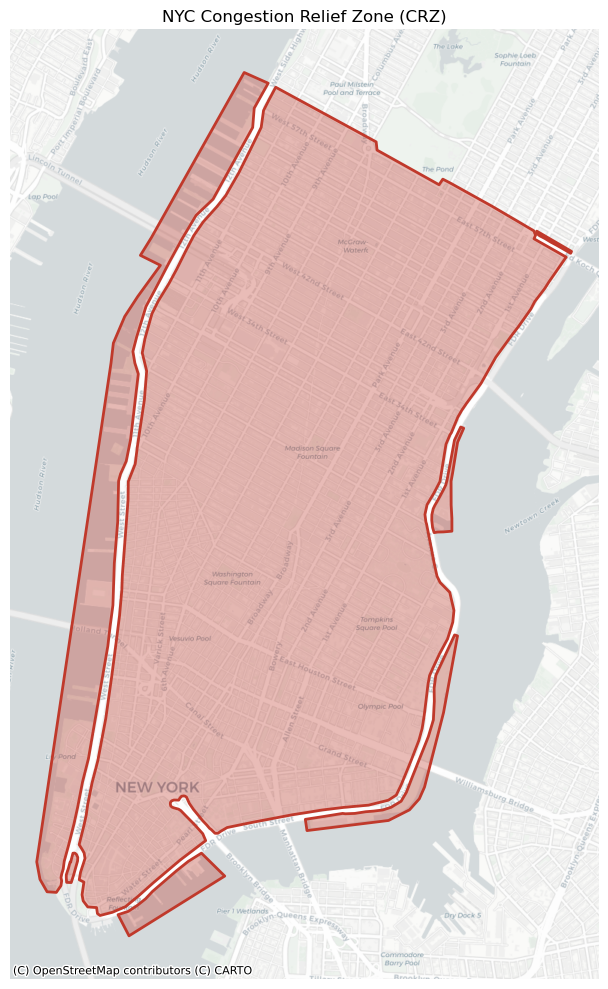

In [3]:
crz = gpd.read_file(ROOT / "data" / "raw" / "crz" / "crz_boundary.geojson").to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(8, 10))
crz.plot(ax=ax, facecolor="#c0392b55", edgecolor="#c0392b", linewidth=2)
cx.add_basemap(ax, source=cx.providers.CartoDB.Positron)
ax.set_axis_off()
ax.set_title("NYC Congestion Relief Zone (CRZ)")
plt.tight_layout()
plt.show()
